<div style='text-align: center; padding: 30px'>
  <h1><strong>Time Series</strong></h1>
  <h3><strong>Heriberto Espino Montelongo</strong></h1>
</div>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file = r'cryptos-index.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

# **PORTFOLIO**

In [4]:
pbuy = data[['XRP', 'TRX', 'LEO', 'PP']]

In [5]:
# create an 'index' column in the portfolio with his weight
pbuy.loc[:, 'Portfolio'] = pbuy['XRP'] * 0.06577 + pbuy['TRX'] * 0.22764 + pbuy['LEO'] * 0.70659

/tmp/ipykernel_77938/2985541625.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pbuy.loc[:, 'Portfolio'] = pbuy['XRP'] * 0.06577 + pbuy['TRX'] * 0.22764 + pbuy['LEO'] * 0.70659


In [6]:
pbuy

,XRP,TRX,LEO,PP,Portfolio
Date,,,,,
2021-10-07 00:00:00+00:00,1.068026,0.095514,2.899025,46625.150251,2.140409
2021-10-08 00:00:00+00:00,1.062891,0.097670,2.780317,46759.770727,2.056684
2021-10-09 00:00:00+00:00,1.159926,0.102870,2.838253,47620.269502,2.105187
2021-10-10 00:00:00+00:00,1.138453,0.097748,2.769014,47435.634377,2.053685
2021-10-11 00:00:00+00:00,1.137888,0.097162,2.742823,49773.467955,2.035008
...,...,...,...,...,...
2025-03-10 00:00:00+00:00,2.018294,0.229486,9.747614,67655.560543,7.072550
2025-03-11 00:00:00+00:00,2.166916,0.224426,9.882753,71379.506151,7.176661
2025-03-12 00:00:00+00:00,2.240755,0.222995,9.709141,72115.729729,7.058519


In [7]:
returnsOB = pbuy.pct_change().dropna()

In [8]:
inv_pob_720 = []    # investment portfolio only buy
investment = 1

for day in range(len(returnsOB) - 720, len(returnsOB)):
    investment = (1 + returnsOB['Portfolio'].iloc[day]) * investment
    inv_pob_720.append(investment)

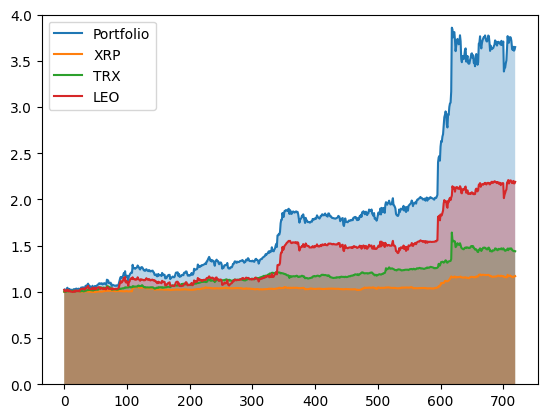

In [9]:
# Calculate the contributions of each crypto to the portfolio
weights = [0.06577, 0.22764, 0.70659]
contributions = pd.DataFrame(index=returnsOB.index)

for i, crypto in enumerate(['XRP', 'TRX', 'LEO']):
    contributions[f'{crypto}_contribution'] = returnsOB[crypto] * weights[i]

contributions['Portfolio_contribution'] = contributions.sum(axis=1)

# Calculate the investment portfolio only buy
inv_pob_720 = []
investment = 1

for day in range(len(contributions) - 720, len(contributions)):
    investment = (1 + contributions['Portfolio_contribution'].iloc[day]) * investment
    inv_pob_720.append(investment)

# Calculate the investment XRP only buy
inv_XRP_720 = []
investment = 1

for day in range(len(contributions) - 720, len(contributions)):
    investment = (1 + contributions['XRP_contribution'].iloc[day]) * investment
    inv_XRP_720.append(investment)


# Calculate the investment TRX only buy
inv_TRX_720 = []
investment = 1

for day in range(len(contributions) - 720, len(contributions)):
    investment = (1 + contributions['TRX_contribution'].iloc[day]) * investment
    inv_TRX_720.append(investment)


# Calculate the investment LEO only buy
inv_LEO_720 = []
investment = 1

for day in range(len(contributions) - 720, len(contributions)):
    investment = (1 + contributions['LEO_contribution'].iloc[day]) * investment
    inv_LEO_720.append(investment)



# plot the investment portfolio only buy
plt.plot(inv_pob_720, label='Portfolio')
plt.plot(inv_XRP_720, label='XRP')
plt.plot(inv_TRX_720, label='TRX')
plt.plot(inv_LEO_720, label='LEO')

# Fill the area under the curves
plt.fill_between(range(len(inv_pob_720)), inv_pob_720, alpha=0.3)
plt.fill_between(range(len(inv_XRP_720)), inv_XRP_720, alpha=0.3)
plt.fill_between(range(len(inv_TRX_720)), inv_TRX_720, alpha=0.3)
plt.fill_between(range(len(inv_LEO_720)), inv_LEO_720, alpha=0.3)

plt.ylim(0, 4)
plt.legend()
plt.savefig('06-pesos.svg', format='svg', bbox_inches='tight')
plt.show()

In [10]:
contributions

,XRP_contribution,TRX_contribution,LEO_contribution,Portfolio_contribution
Date,,,,
2021-10-08 00:00:00+00:00,-0.000316,0.005138,-0.028933,-0.024111
2021-10-09 00:00:00+00:00,0.006004,0.012120,0.014724,0.032848
2021-10-10 00:00:00+00:00,-0.001218,-0.011334,-0.017237,-0.029789
2021-10-11 00:00:00+00:00,-0.000033,-0.001365,-0.006683,-0.008081
2021-10-12 00:00:00+00:00,-0.002082,-0.003873,0.015712,0.009756
...,...,...,...,...
2025-03-10 00:00:00+00:00,-0.003583,-0.002377,0.000983,-0.004977
2025-03-11 00:00:00+00:00,0.004843,-0.005019,0.009796,0.009620
2025-03-12 00:00:00+00:00,0.002241,-0.001451,-0.012413,-0.011623


In [11]:
inv_pob_360 = []    # investment portfolio only buy
investment = 1

for day in range(len(returnsOB) - 360, len(returnsOB)):
    investment = (1 + returnsOB['Portfolio'].iloc[day]) * investment
    inv_pob_360.append(investment)

In [12]:
inv_pob = []    # investment portfolio only buy
investment = 1

for day in range(0, len(returnsOB)):
    investment = (1 + returnsOB['Portfolio'].iloc[day]) * investment
    inv_pob.append(investment)

In [13]:
inv_pob_30 = []    # investment portfolio only buy
investment = 1

for day in range(len(returnsOB) - 30, len(returnsOB)):
    investment = (1 + returnsOB['Portfolio'].iloc[day]) * investment
    inv_pob_30.append(investment)

# **PONDERED PORTFOLIO**

In [14]:
inv_pp_720 = []         # investment pondered portfolio
investment = 1

for day in range(len(returnsOB) - 720, len(returnsOB)):
    
    investment = (1 + returnsOB['PP'].iloc[day]) * investment
    inv_pp_720.append(investment)

In [15]:
inv_pp_360 = []         # investment pondered portfolio
investment = 1

for day in range(len(returnsOB) - 360, len(returnsOB)):
    
    investment = (1 + returnsOB['PP'].iloc[day]) * investment
    inv_pp_360.append(investment)

In [16]:
inv_pp = []         # investment pondered portfolio
investment = 1

for day in range(0, len(returnsOB)):
    
    investment = (1 + returnsOB['PP'].iloc[day]) * investment
    inv_pp.append(investment)

In [17]:
inv_pp_30 = []         # investment pondered portfolio
investment = 1

for day in range(len(returnsOB) - 30, len(returnsOB)):
    
    investment = (1 + returnsOB['PP'].iloc[day]) * investment
    inv_pp_30.append(investment)

# **CFD PORTFOLIO**

In [18]:
weights = pd.read_csv('portfolio-cfd.csv')

In [19]:
pcfd = data  # portfolio cfd

In [20]:
returnsCFD = pcfd.pct_change().dropna()

In [21]:
# get the weights 
for w in weights.columns:                       # for each crypto
    returnsCFD[w] = returnsCFD[w] * weights[w][0]   # multiply by the weight 

In [22]:
returnsCFD['Portfolio'] = returnsCFD.sum(axis=1)    # sum the columns to get the portfolio return

In [23]:
inv_cfd_720 = []
investment = 1

for day in range(len(returnsCFD) - 720, len(returnsCFD)):
    investment = (1 + returnsCFD['Portfolio'].iloc[day]) * investment
    inv_cfd_720.append(investment)

In [24]:
inv_cfd_360 = []
investment = 1

for day in range(len(returnsCFD) - 360, len(returnsCFD)):
    investment = (1 + returnsCFD['Portfolio'].iloc[day]) * investment
    inv_cfd_360.append(investment)

In [25]:
inv_cfd = []
investment = 1

for day in range(0, len(returnsCFD)):
    investment = (1 + returnsCFD['Portfolio'].iloc[day]) * investment
    inv_cfd.append(investment)

In [26]:
inv_cfd_30 = []
investment = 1

for day in range(len(returnsCFD) - 30, len(returnsCFD)):
    investment = (1 + returnsCFD['Portfolio'].iloc[day]) * investment
    inv_cfd_30.append(investment)

# **SAVE THE 3 PORTFOLIOS**

In [27]:
# returnsCFD['Portfolio']
# returnsOB['Portfolio']
# returnsOB['PP']

portfolios = pd.concat([returnsCFD['Portfolio'], returnsOB['Portfolio'], returnsOB['PP']], axis=1)
portfolios.columns = ['CFD', 'OB', 'PP']

portfolios.to_csv('portfolios-returns.csv')


# **COMPARISON: HOW $1 DOLAR WOULD LOOK NOW**

In [28]:
# Set the style and color palette
sns.set(style="whitegrid")
sns.set_palette("Set2", 3)

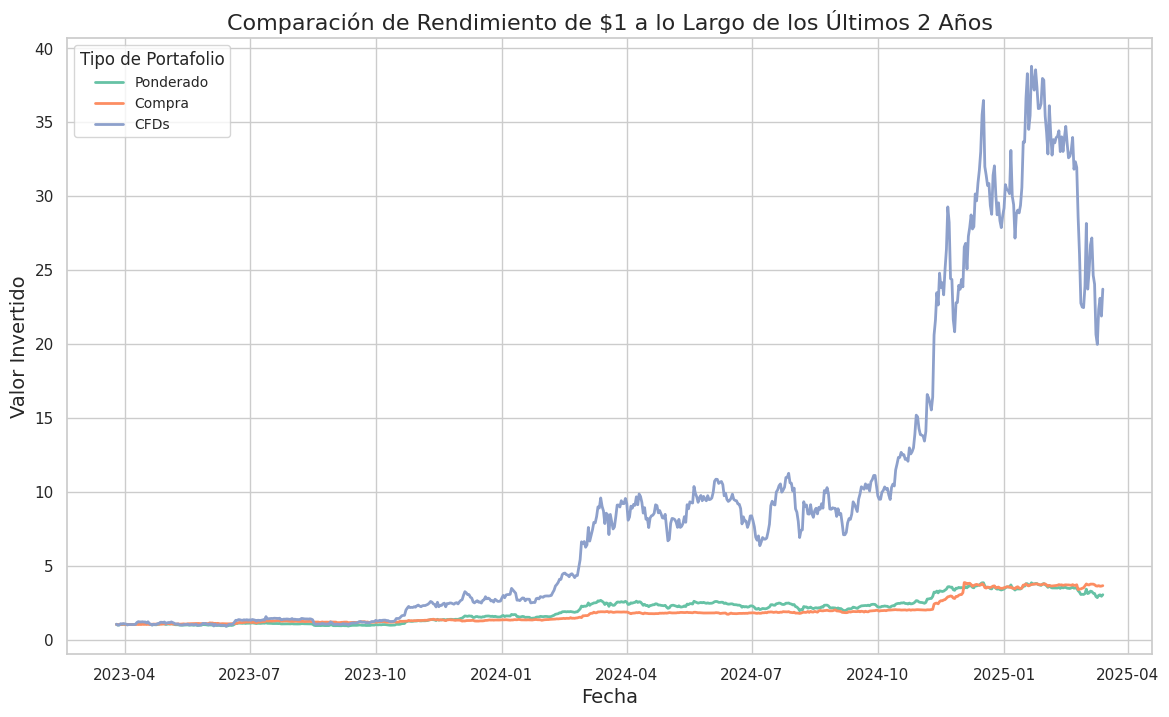

In [29]:
# Create the DataFrame for comparison
comparision_720 = pd.DataFrame({
    'Ponderado': inv_pp_720,
    'Compra': inv_pob_720,
    'CFDs': inv_cfd_720
})

# Create a new date range ending on 14/03/2025
date_range = pd.date_range(end='2025-03-14', periods=len(comparision_720))
comparision_720.index = date_range

# Plot the data
plt.figure(figsize=(14, 8))
sns.lineplot(data=comparision_720, dashes=False, linewidth=2)   

# Add titles and labels
plt.title('Comparación de Rendimiento de $1 a lo Largo de los Últimos 2 Años', fontsize=16)
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Valor Invertido', fontsize=14)

# Add a legend
plt.legend(title='Tipo de Portafolio', fontsize=10, title_fontsize='12')

plt.savefig('svg/06-comparacion-2y.svg', format='svg', bbox_inches='tight')
# Show the plot
plt.show()


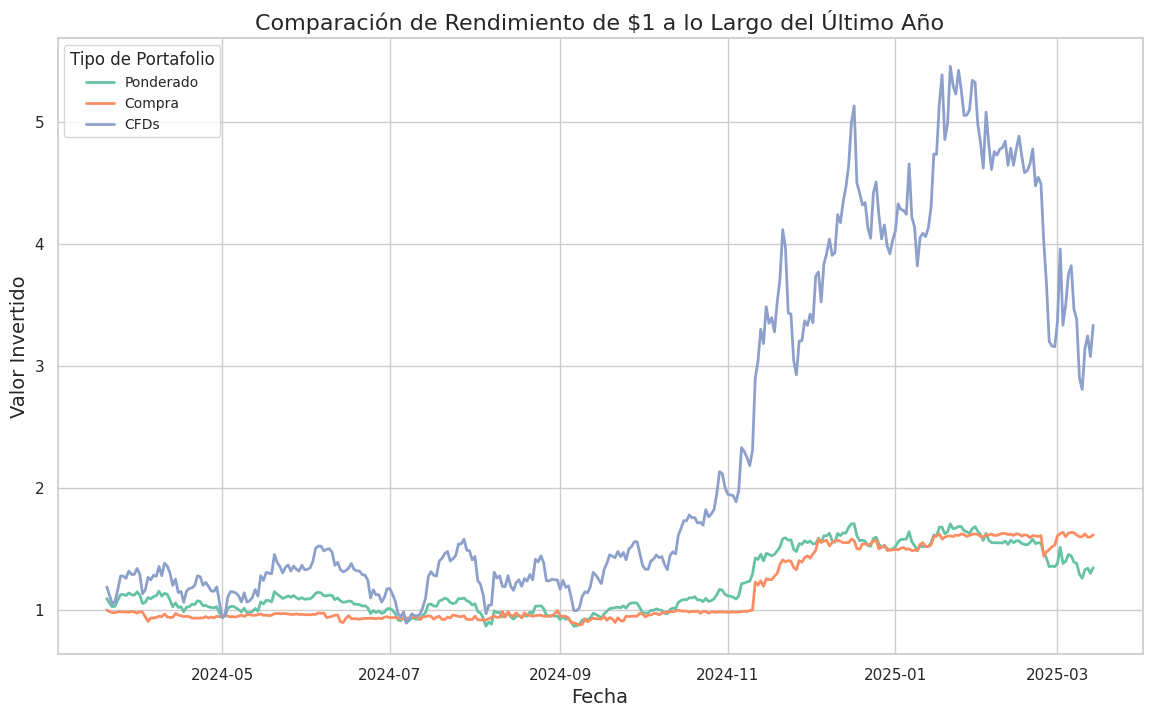

In [30]:
# Create the DataFrame for comparison
comparision_360 = pd.DataFrame({
    'Ponderado': inv_pp_360,
    'Compra': inv_pob_360,
    'CFDs': inv_cfd_360
})

# Create a new date range ending on 14/03/2025
date_range = pd.date_range(end='2025-03-14', periods=len(comparision_360))
comparision_360.index = date_range

# Plot the data
plt.figure(figsize=(14, 8))
sns.lineplot(data=comparision_360, dashes=False, linewidth=2)   

# Add titles and labels
plt.title('Comparación de Rendimiento de $1 a lo Largo del Último Año', fontsize=16)
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Valor Invertido', fontsize=14)

# Add a legend
plt.legend(title='Tipo de Portafolio', fontsize=10, title_fontsize='12')

plt.savefig('svg/06-comparacion-1y.svg', format='svg', bbox_inches='tight')
# Show the plot
plt.show()

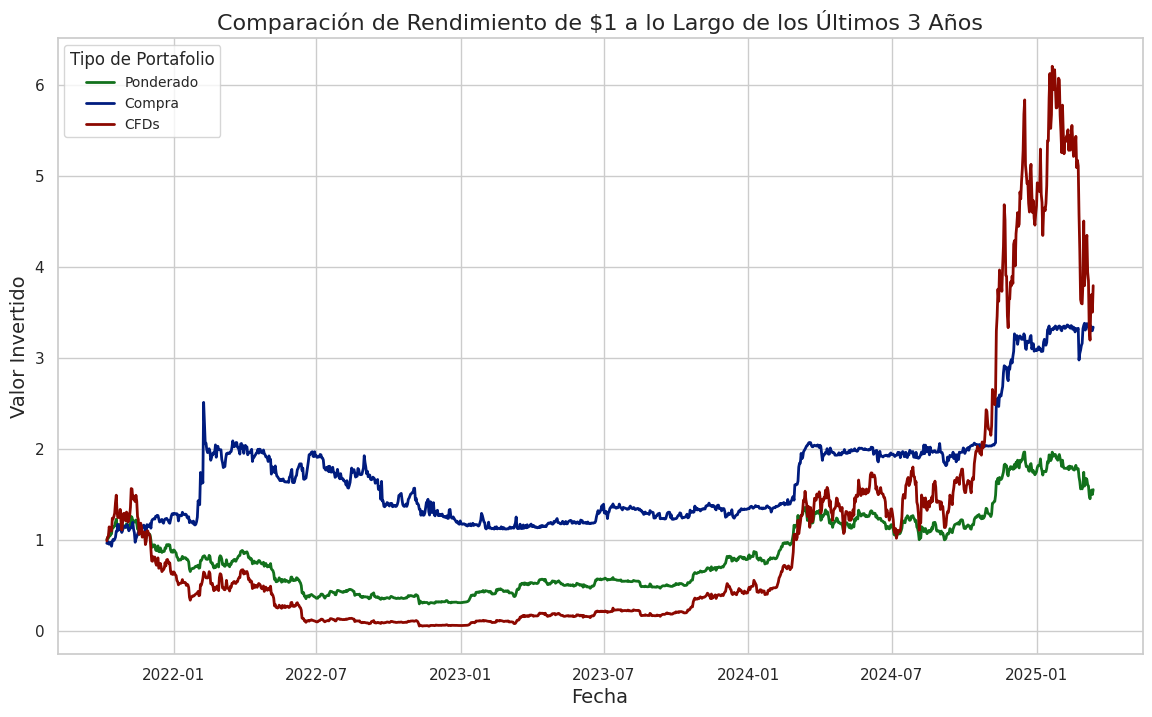

In [31]:
# Create the DataFrame for comparison
comparision_1080 = pd.DataFrame({
    'Ponderado': inv_pp,
    'Compra': inv_pob,
    'CFDs': inv_cfd
})

# Create a new date range ending on 14/03/2025
date_range = pd.date_range(end='2025-03-14', periods=len(comparision_1080))
comparision_1080.index = date_range

# Define custom colors for the lines
custom_palette = {'Ponderado': '#12711c', 'Compra': '#001c7f', 'CFDs': '#8c0800'}

# Plot the data
plt.figure(figsize=(14, 8))
sns.lineplot(data=comparision_1080, dashes=False, linewidth=2, palette=custom_palette)   

# Add titles and labels
plt.title('Comparación de Rendimiento de $1 a lo Largo de los Últimos 3 Años', fontsize=16)
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Valor Invertido', fontsize=14)

# Add a legend
plt.legend(title='Tipo de Portafolio', fontsize=10, title_fontsize='12')

plt.savefig('svg/06-comparacion-3y.svg', format='svg', bbox_inches='tight')
# Show the plot
plt.show()


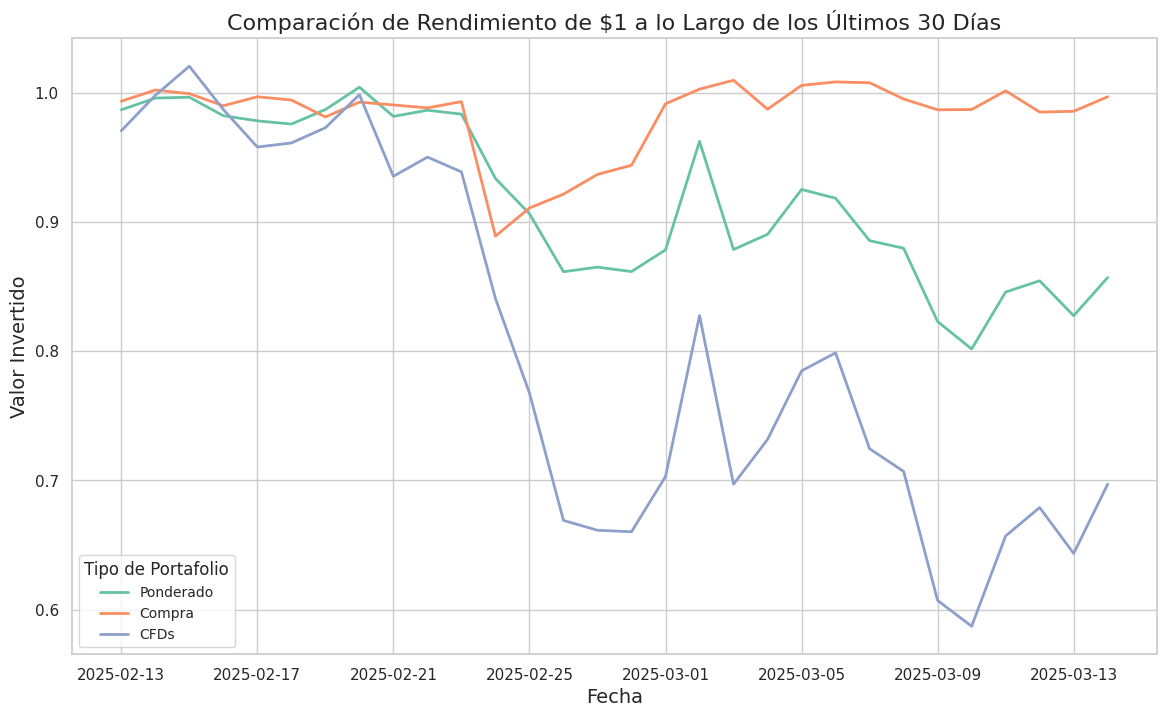

In [ ]:
# Create the DataFrame for comparison
comparision_30 = pd.DataFrame({
    'Ponderado': inv_pp_30,
    'Compra': inv_pob_30,
    'CFDs': inv_cfd_30
})

# Create a new date range ending on 14/03/2025
date_range = pd.date_range(end='2025-03-14', periods=len(comparision_30))
comparision_30.index = date_range

# Plot the data
plt.figure(figsize=(14, 8))
sns.lineplot(data=comparision_30, dashes=False, linewidth=2)   

# Add titles and labels
plt.title('Comparación de Rendimiento de $1 a lo Largo de los Últimos 30 Días', fontsize=16)
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Valor Invertido', fontsize=14)

# Add a legend
plt.legend(title='Tipo de Portafolio', fontsize=10, title_fontsize='12')

plt.savefig('svg/06-comparacion-30d.svg', format='svg', bbox_inches='tight')
# Show the plot
plt.show()